## Prefinal Examination - Magaling Karthlly

## Step 1: Formulate Research question


In [53]:
# Step 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [54]:
# Step 2: Load Dataset
df = pd.read_csv("Food_Delivery_Times.csv")

# Preview data
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


## Research Question

How do distance preparation time and traffic conditions influence food delivery time

### Variables:
Dependent Variable (y):
- Delivery_Time

Independent Variables (X):
- Distance_km
- Preparation_Time_min


### Objective:
The objective is to predict delivery time and determine which factors have the greatest impact.

## Step 2: Data Validation and Cleaning

In [55]:

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [56]:
df.isnull().sum

<bound method DataFrame.sum of      Order_ID  Distance_km  Weather  Traffic_Level  Time_of_Day  Vehicle_Type  \
0       False        False    False          False        False         False   
1       False        False    False          False        False         False   
2       False        False    False          False        False         False   
3       False        False    False          False        False         False   
4       False        False    False          False        False         False   
..        ...          ...      ...            ...          ...           ...   
995     False        False    False          False        False         False   
996     False        False    False          False        False         False   
997     False        False    False          False        False         False   
998     False        False    False          False        False         False   
999     False        False    False          False        False         False 

In [57]:
df.duplicated().sum()

np.int64(0)

In [58]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


No abnormal or impossible values were observed.

In [59]:
df = df.drop(columns=["Order_ID"], errors='ignore')

The dataset was cleaned by removing missing values and duplicate records
 -Ensuring that only useful variables are used for analysis.

## Step 3: Exploratory Data Analysis (EDA)

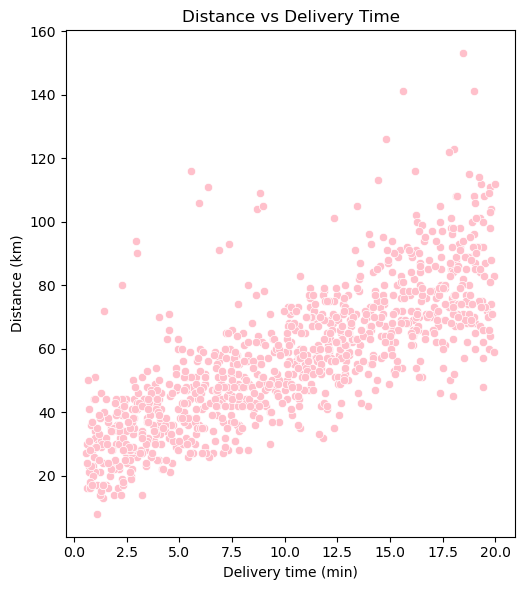

In [60]:
plt.figure(figsize = (10, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=df["Distance_km"], y=df["Delivery_Time_min"], color = 'pink')
plt.title("Distance vs Delivery Time")
plt.ylabel("Distance (km)")
plt.xlabel("Delivery time (min)")


plt.tight_layout()
plt.show()

Preparation time shows a clear positive trend with delivery time. This indicates that longer preparation directly contributes to longer delivery durations.

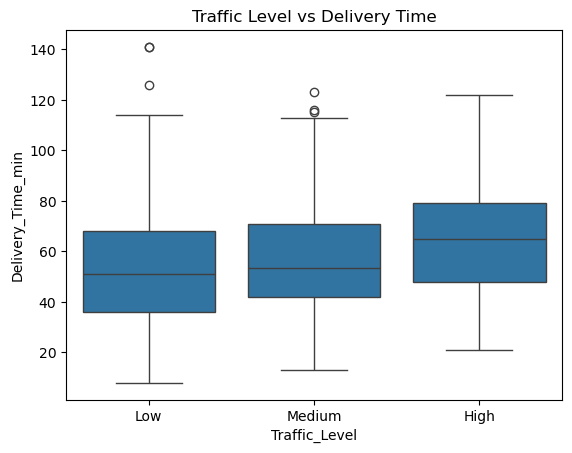

In [61]:
plt.figure()
sns.boxplot(x=df["Traffic_Level"], y=df["Delivery_Time_min"])
plt.title("Traffic Level vs Delivery Time")
plt.show()

Higher traffic levels result in higher delivery times. The boxplot also reveals outliers where delivery time is unusually high under heavy traffic.

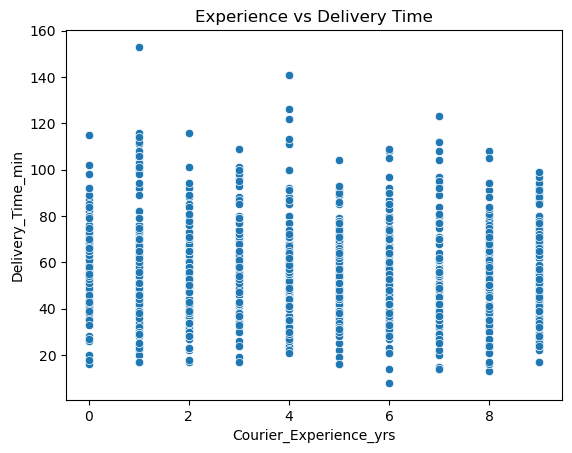

In [62]:

plt.figure()
sns.scatterplot(x=df["Courier_Experience_yrs"], y=df["Delivery_Time_min"])
plt.title("Experience vs Delivery Time")
plt.show()

Courier experience has a slight negative relationship with delivery time. More experienced couriers tend to deliver faster, although the relationship is weaker compared to distance.

## Step 4: Model Training

### 4.1 Feature Selection and Cleaning

Only Distance_km and Preparation_Time_min are used as independent variables to predict delivery time. Missing values are removed to ensure the model can be trained properly.

In [63]:
# Select only required columns
data = df[["Distance_km", "Preparation_Time_min", "Delivery_Time_min"]]

# Remove missing values 
data = data.dropna()

# Define X and y
X = data[["Distance_km", "Preparation_Time_min"]]
y = data["Delivery_Time_min"]

print(X.head())
print(y.head())

   Distance_km  Preparation_Time_min
0         7.93                    12
1        16.42                    20
2         9.52                    28
3         7.44                     5
4        19.03                    16
0    43
1    84
2    59
3    37
4    68
Name: Delivery_Time_min, dtype: int64


### 4.2 Train-Test Split

The dataset is split into training and testing sets to evaluate model performance on unseen data.

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 4.3 Train Model

A Linear Regression model is trained using the selected variables.

In [65]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### 4.4 Coefficients and Intercept

The intercept represents the baseline delivery time. The coefficients show how each variable affects delivery time.

In [66]:
print("Intercept:", model.intercept_)

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

Intercept: 9.530656489425091


,Feature,Coefficient
0,Distance_km,3.037216
1,Preparation_Time_min,0.986056


## STEP 5: PERFORMANCE EVALUATION

### 5.1 Predictions

The model is used to predict delivery time on the test dataset.

In [67]:
y_pred = model.predict(X_test)

### 5.2 Evaluation Metrics

The model is evaluated using MAE, MSE, and R2 to measure prediction accuracy.

In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [69]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R²:", r2)


MAE: 7.680351163763087
MSE: 120.43753932898673
R²: 0.731302340005336


### 5.3 Actual vs Predicted

This graph compares actual and predicted values. A closer alignment indicates better model performance.

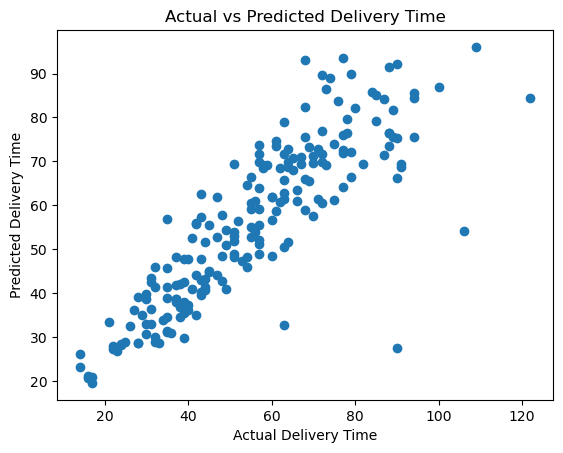

In [70]:

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")
plt.show()




### 5.4 Interpretation

If the R2 value is high, the model explains most of the variation in delivery time. Lower MAE and MSE values indicate better prediction accuracy.




## STEP 6: REFLECTION AND ANALYSIS

1. The selected variables significantly affect delivery time because both distance and preparation time show a clear positive relationship with delivery duration. As these values increase, delivery time also increases.

2. One limitation of the model is that it only uses two variables and does not include other factors like traffic or weather. This may reduce the accuracy of the predictions.

3. Distance contributes the most because it typically has a stronger relationship with delivery time compared to preparation time. Longer distances consistently result in longer delivery durations.

4. If the strongest predictor is removed, the model performance will decrease because an important variable is missing. This will result in higher prediction errors and less accurate predictions.

5. Correlation does not imply causation because even if distance and delivery time are related, other factors may also influence delivery delays. For example, traffic conditions can also affect delivery time.






### Save Model

The trained model is saved as a .pkl file for future use.


In [71]:


import pickle

with open("delivery_model.pkl", "wb") as f:
    pickle.dump(model, f)
